In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Data Overview

In [9]:
import pandas as pd

# Load the dataset
adult = pd.read_csv(r"C:\Users\young\OneDrive\文档\ml\Homework5\adult.csv")

# Preview the data
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [10]:
adult.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [11]:
# Check dataset shape
adult.shape

(48842, 15)

# check for missing and duplicate values 

In [12]:
adult= adult.replace(r'^\s*\?$', np.nan, regex=True)

adult.isnull().sum()

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

In [14]:
adult.duplicated().sum()

np.int64(52)

# Data cleaning

In [18]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [15]:
# Copy original dataset
df = adult.copy()

# Remove duplicate rows
df = df.drop_duplicates()

# Replace ? with missing values
df = df.replace(r'^\s*\?$', np.nan, regex=True)

# Impute missing categorical values with "Unknown"
for col in ["workclass", "occupation", "native-country"]:
    df[col] = df[col].fillna("Unknown")

# Drop less useful or redundant features
df = df.drop(columns=["fnlwgt", "education"])


The `fnlwgt` feature was removed because it is a census weighting variable and is generally not useful for predictive modeling. 

The `education` feature was also removed because it was highly redundant with `educational-num`, which already provides a numeric representation of education level.

# Feature engineering


In [16]:
# Binary indicators for capital activity
df["has_capital_gain"] = (df["capital-gain"] > 0).astype(int)
df["has_capital_loss"] = (df["capital-loss"] > 0).astype(int)

# Net capital activity
df["capital_net"] = df["capital-gain"] - df["capital-loss"]

# Log transform to reduce effect of extreme values
df["capital_gain_log"] = np.log1p(df["capital-gain"])

# Work intensity feature
df["work_intensity"] = df["hours-per-week"] / (df["age"] + 1)

# Data Processing

In [23]:
# Define numeric and categorical columns

num_cols = [
    "age",
    "educational-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "capital_net",
    "capital_gain_log",
    "work_intensity"
]

cat_cols = [
    "workclass",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "gender",
    "native-country",
    "has_capital_gain",
    "has_capital_loss"
]

# Create X

X = pd.concat([
    df[num_cols],
    pd.get_dummies(df[cat_cols], drop_first=True).astype(int)
], axis=1)

# Create y
y = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

# Scale numeric columns only

scaler = MinMaxScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [20]:
# Final shapes
print("Training features shape:", X_train.shape)
print("Test features shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)

Training features shape: (39032, 89)
Test features shape: (9758, 89)
Training labels shape: (39032,)
Test labels shape: (9758,)


## Data Cleaning, Preprocessing and Feature Engineering

The dataset was cleaned by removing duplicate rows and replacing question marks (`?`) with missing values.

Missing categorical values in `workclass`, `occupation`, and `native-country` were imputed using the category `"Unknown"` in order to preserve more training data.

The `fnlwgt` feature was removed because it is a census weighting variable and is generally not useful for predictive modeling. The `education` feature was also removed because it was highly redundant with `educational-num`, which already provides a numeric representation of education level.

Several engineered features were added:

- `has_capital_gain`: whether the person reported any capital gain
- `has_capital_loss`: whether the person reported any capital loss
- `capital_net`: capital gain minus capital loss
- `capital_gain_log`: log-transformed capital gain
- `work_intensity`: hours worked per week divided by age

Numeric and categorical columns were separated before preprocessing. Categorical variables were one-hot encoded, while numeric features were scaled using MinMaxScaler.

Finally, the target variable (`income`) was converted into a binary label for neural network classification.

In [21]:
tf.random.set_seed(42)

In [41]:
# Build baseline model
inputs = keras.Input(shape=(X_train.shape[1],))

x = layers.Dense(12, activation='relu')(inputs)
x = layers.Dense(6, activation='relu')(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 89)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 12)             │         1,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,165 (4.55 KB)

 Trainable params: 1,165 (4.55 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [43]:
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

scores = model.evaluate(X_test, y_test, verbose = 1)

Epoch 1/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8115 - loss: 0.3980 - val_accuracy: 0.8407 - val_loss: 0.3450
Epoch 2/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8391 - loss: 0.3400 - val_accuracy: 0.8432 - val_loss: 0.3347
Epoch 3/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8466 - loss: 0.3295 - val_accuracy: 0.8471 - val_loss: 0.3288
Epoch 4/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8499 - loss: 0.3231 - val_accuracy: 0.8498 - val_loss: 0.3253
Epoch 5/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8519 - loss: 0.3191 - val_accuracy: 0.8494 - val_loss: 0.3233
Epoch 6/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8529 - loss: 0.3163 - val_accuracy: 0.8519 - val_loss: 0.3218
Epoch 7/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8539 - loss: 0.3142 - val_accuracy: 0.8524 - val_loss: 0.3206
Epoch 8/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8548 - loss: 0.3126 - val_accuracy: 0.

In [44]:
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [45]:
# evaluate the model using the test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("\n Test Set Evaluation:") 
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

 Test Set Evaluation:
Test Accuracy: 0.8503
Test Precision: 0.6986
Test Recall: 0.6588
Test F1 Score: 0.6781
Test ROC AUC Score: 0.9084


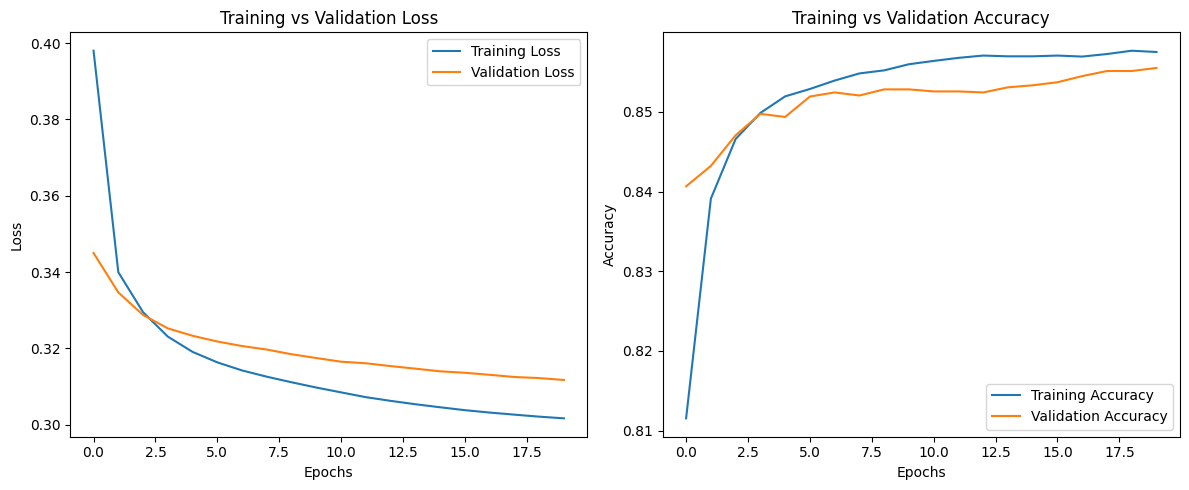

In [46]:
# Plot training and validation loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

The baseline neural network used a small funnel architecture with two hidden layers containing 12 and 6 neurons. ReLU activation was used in the hidden layers, while the output layer used sigmoid activation for binary classification.

The model was trained using the Adam optimizer, binary cross-entropy loss, a batch size of 32, and 20 epochs.

The baseline model showed stable learning behavior. Both training and validation loss gradually decreased, while training and validation accuracy steadily increased. The curves remained close together throughout training, suggesting good generalization with minimal overfitting.

However, the accuracy improvements began to plateau during later epochs, indicating that the small baseline architecture may have had limited model capacity for capturing more complex patterns in the dataset.

Round 1 — Same Capacity + Dropout Regularization

Since the baseline model showed some signs of overfitting, Round 1 focused on reducing overfitting rather than simply increasing model complexity. Dropout was added to make the model less dependent on specific neurons during training and to improve generalization. Later rounds then tested whether increasing model capacity could improve performance without making the validation curves worse.

In [47]:
# Round 1 model
tf.random.set_seed(42)

inputs = keras.Input(shape=(X_train.shape[1],))

x = layers.Dense(12, activation='relu')(inputs)
x = layers.Dropout(0.2)(x)

x = layers.Dense(6, activation='relu')(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 89)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 12)             │         1,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,165 (4.55 KB)

 Trainable params: 1,165 (4.55 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Compile model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [49]:
# Train model
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

scores = model.evaluate(X_test, y_test, verbose=1)

Epoch 1/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7908 - loss: 0.4478 - val_accuracy: 0.8344 - val_loss: 0.3531
Epoch 2/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8268 - loss: 0.3771 - val_accuracy: 0.8395 - val_loss: 0.3426
Epoch 3/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8288 - loss: 0.3650 - val_accuracy: 0.8455 - val_loss: 0.3347
Epoch 4/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8364 - loss: 0.3550 - val_accuracy: 0.8480 - val_loss: 0.3312
Epoch 5/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8381 - loss: 0.3478 - val_accuracy: 0.8514 - val_loss: 0.3272
Epoch 6/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8424 - loss: 0.3430 - val_accuracy: 0.8528 - val_loss: 0.3264
Epoch 7/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8421 - loss: 0.3399 - val_accuracy: 0.8535 - val_loss: 0.3244
Epoch 8/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8447 - loss: 0.3355 - val_accuracy: 0

In [50]:
# Evaluate model
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("\nRound 1 Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Round 1 Test Set Evaluation:
Test Accuracy: 0.8535
Test Precision: 0.7467
Test Recall: 0.5869
Test F1 Score: 0.6572
Test ROC AUC Score: 0.9065


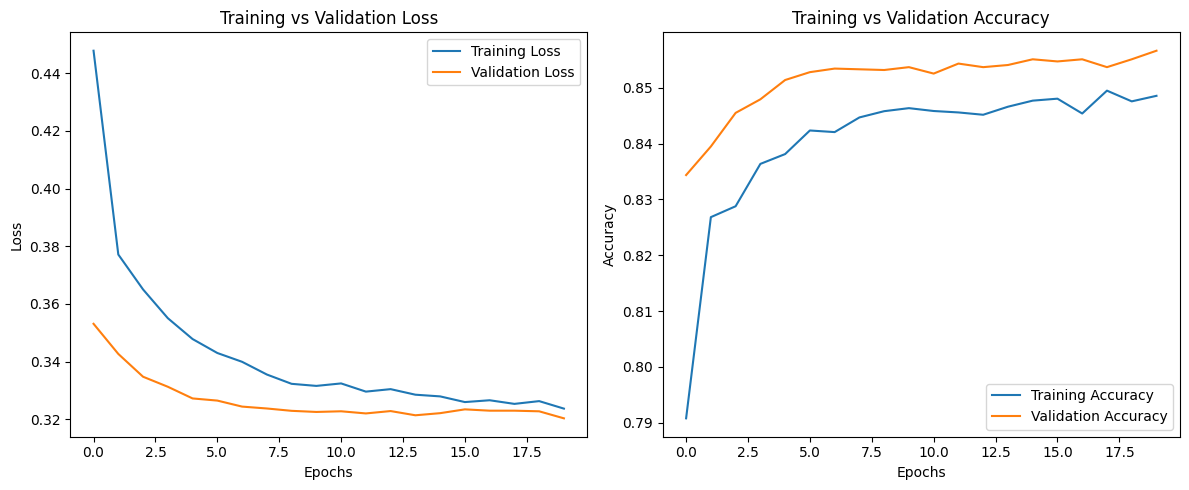

In [51]:
# Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In Round 1, dropout regularization was added to the baseline neural network while keeping the same funnel architecture (12 → 6 → 1).

Both training and validation loss steadily decreased throughout training, while training and validation accuracy gradually improved over the epochs. The curves remained close together and appeared smoother compared to the baseline model.

Validation accuracy stayed slightly higher than training accuracy during most epochs, which suggests that dropout helped reduce overfitting by preventing the network from relying too heavily on specific neurons during training.

However, overall performance improved only slightly compared to the baseline model, indicating that regularization alone was not sufficient to significantly improve model capacity. The model may still be slightly underfitting the dataset.

# Round 2: deeper funnel model 24 -> 12 -> 6

In [53]:
inputs = keras.Input(shape=(X_train.shape[1],))

x = layers.Dense(24, activation='relu')(inputs)
x = layers.Dense(12, activation='relu')(x)
x = layers.Dense(6, activation='relu')(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

scores = model.evaluate(X_test, y_test, verbose=1)

Epoch 1/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8228 - loss: 0.3765 - val_accuracy: 0.8433 - val_loss: 0.3372
Epoch 2/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8461 - loss: 0.3306 - val_accuracy: 0.8485 - val_loss: 0.3278
Epoch 3/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8499 - loss: 0.3214 - val_accuracy: 0.8523 - val_loss: 0.3233
Epoch 4/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8529 - loss: 0.3163 - val_accuracy: 0.8540 - val_loss: 0.3207
Epoch 5/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8549 - loss: 0.3124 - val_accuracy: 0.8547 - val_loss: 0.3191
Epoch 6/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8561 - loss: 0.3094 - val_accuracy: 0.8551 - val_loss: 0.3175
Epoch 7/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8569 - loss: 0.3069 - val_accuracy: 0.8556 - val_loss: 0.3165
Epoch 8/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8583 - loss: 0.3046 - val_accuracy: 0.

In [54]:
# Evaluate model
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("\nRound 2 Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Round 2 Test Set Evaluation:
Test Accuracy: 0.8482
Test Precision: 0.6901
Test Recall: 0.6644
Test F1 Score: 0.6770
Test ROC AUC Score: 0.9071


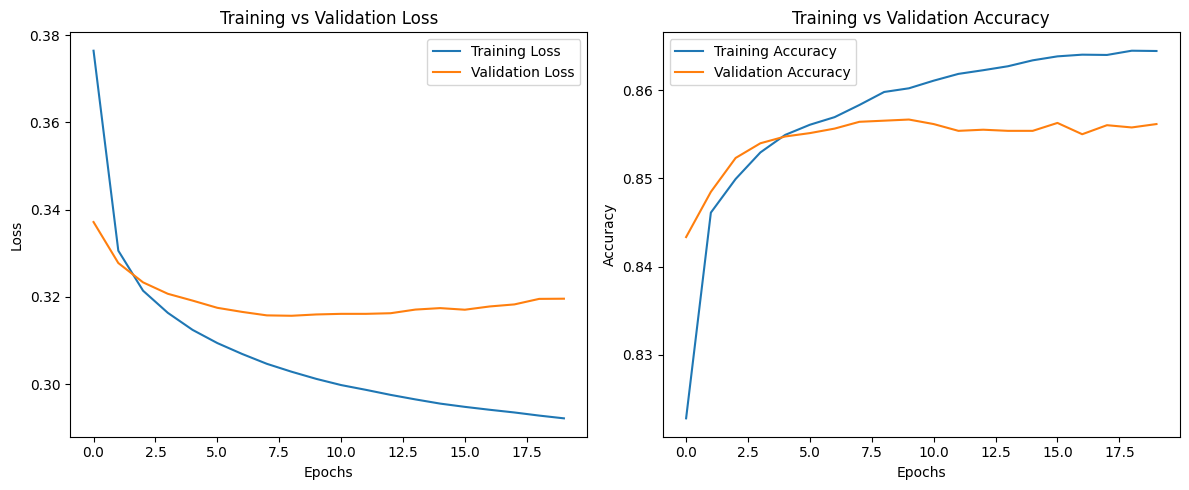

In [55]:
# Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Round 2 increased the model complexity by using more neurons than the baseline model. Training loss steadily decreased, while validation loss began to plateau and slightly increase after several epochs, suggesting mild overfitting.

Training accuracy continued improving, but validation accuracy remained relatively stable around 0.855, showing limited improvement in generalization performance.

Overall, the larger network learned faster, but the additional complexity only slightly improved performance.

Test Accuracy ≈ 0.848
Test ROC AUC ≈ 0.907

# Round 3: Round 2 + L2 Regularization


In [57]:
tf.random.set_seed(42)

inputs = keras.Input(shape=(X_train.shape[1],))

x = layers.Dense(
    24,
    activation='relu',
    kernel_regularizer=keras.regularizers.l2(0.001)
)(inputs)

x = layers.Dense(
    12,
    activation='relu',
    kernel_regularizer=keras.regularizers.l2(0.001)
)(x)

x = layers.Dense(
    6,
    activation='relu',
    kernel_regularizer=keras.regularizers.l2(0.001)
)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

scores = model.evaluate(X_test, y_test, verbose=1)

Epoch 1/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8217 - loss: 0.4095 - val_accuracy: 0.8417 - val_loss: 0.3614
Epoch 2/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8438 - loss: 0.3559 - val_accuracy: 0.8477 - val_loss: 0.3504
Epoch 3/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8475 - loss: 0.3478 - val_accuracy: 0.8487 - val_loss: 0.3464
Epoch 4/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8488 - loss: 0.3443 - val_accuracy: 0.8503 - val_loss: 0.3442
Epoch 5/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8494 - loss: 0.3419 - val_accuracy: 0.8515 - val_loss: 0.3426
Epoch 6/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8495 - loss: 0.3401 - val_accuracy: 0.8515 - val_loss: 0.3412
Epoch 7/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8498 - loss: 0.3386 - val_accuracy: 0.8531 - val_loss: 0.3398
Epoch 8/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8506 - loss: 0.3373 - val_accuracy: 0.

In [58]:
# Round 3: evaluate model using test set

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("\n Round 3 Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

 Round 3 Test Set Evaluation:
Test Accuracy: 0.8521
Test Precision: 0.8491
Test Recall: 0.8521
Test F1 Score: 0.8504
Test ROC AUC Score: 0.9067


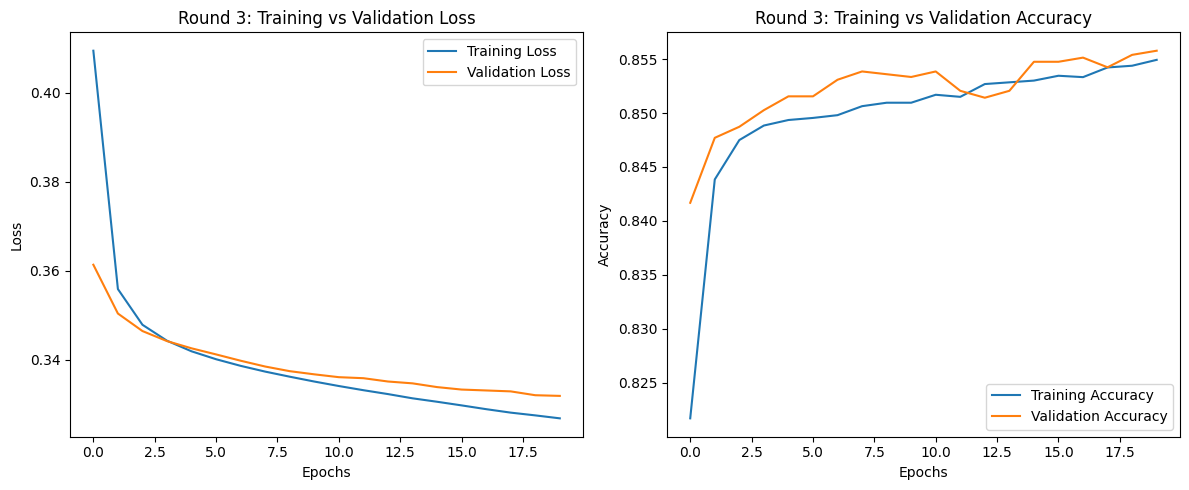

In [59]:
# Round 3: plot training history

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Round 3: Training vs Validation Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Round 3: Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Round 3 used a deeper funnel architecture (24 → 12 → 6 → 1) with L2 regularization to test whether increasing model complexity while controlling overfitting would improve performance.

The model showed stable learning behavior, with both training and validation loss steadily decreasing across epochs. Training and validation accuracy also increased gradually and remained relatively close together, suggesting that the L2 regularization helped limit overfitting despite the deeper architecture.

Compared to Round 2, performance improved only slightly. The model achieved a test accuracy of approximately 0.852 and a ROC AUC score of 0.907. Although the deeper architecture and L2 regularization provided a small performance gain, the improvement was relatively modest, suggesting diminishing returns from adding additional hidden layers.

# Round 4: Dropout + EarlyStopping


In [61]:
inputs = keras.Input(shape=(X_train.shape[1],))

x = layers.Dense(24, activation='relu')(inputs)
x = layers.Dropout(0.2)(x)

x = layers.Dense(12, activation='relu')(x)
x = layers.Dropout(0.2)(x)

x = layers.Dense(6, activation='relu')(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="round4_dropout_earlystop")

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

scores = model.evaluate(X_test, y_test, verbose=1)

Epoch 1/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7884 - loss: 0.4330 - val_accuracy: 0.8416 - val_loss: 0.3457
Epoch 2/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8358 - loss: 0.3536 - val_accuracy: 0.8440 - val_loss: 0.3376
Epoch 3/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8416 - loss: 0.3410 - val_accuracy: 0.8471 - val_loss: 0.3299
Epoch 4/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8457 - loss: 0.3334 - val_accuracy: 0.8504 - val_loss: 0.3273
Epoch 5/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8489 - loss: 0.3293 - val_accuracy: 0.8487 - val_loss: 0.3258
Epoch 6/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8502 - loss: 0.3237 - val_accuracy: 0.8485 - val_loss: 0.3240
Epoch 7/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8532 - loss: 0.3205 - val_accuracy: 0.8521 - val_loss: 0.3224
Epoch 8/20
976/976 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8532 - loss: 0.3176 - val_accuracy: 0.

In [62]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("\nRound 4 Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Round 4 Test Set Evaluation:
Test Accuracy: 0.8487
Test Precision: 0.6982
Test Recall: 0.6485
Test F1 Score: 0.6724
Test ROC AUC Score: 0.9069


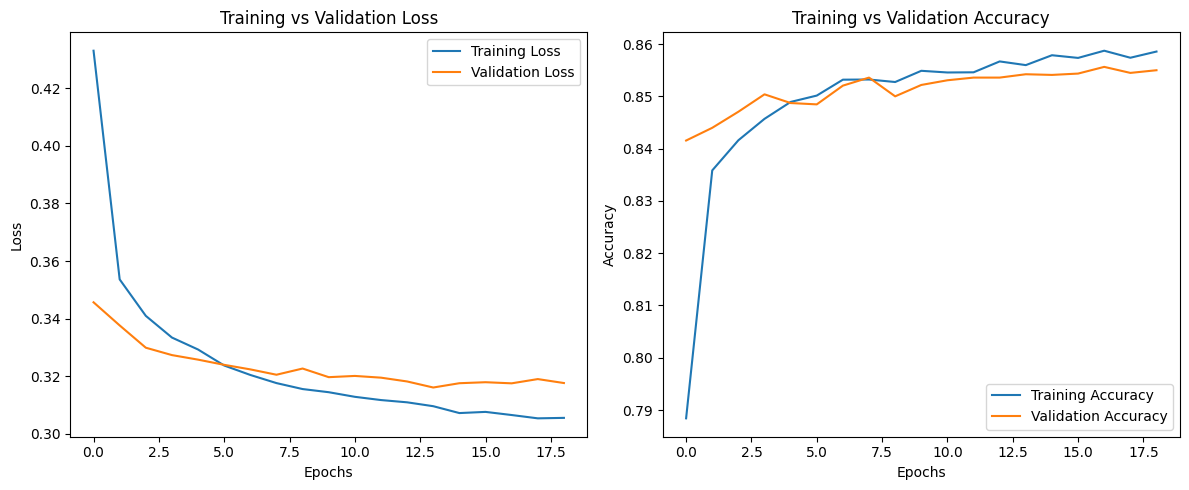

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Round 4 applied dropout with EarlyStopping while keeping the deeper funnel architecture. The purpose was to test whether dropout combined with automatic stopping could reduce overfitting and improve validation behavior.

The training loss continued decreasing throughout training, while the validation loss flattened after the early epochs. Training accuracy also became slightly higher than validation accuracy, suggesting mild overfitting remained present.

Compared to previous rounds, Round 4 produced very similar performance, with a test ROC AUC score of approximately 0.907. The additional regularization slightly stabilized the validation curves but did not substantially improve overall model performance.

Overall, increasing model complexity beyond Round 2 and Round 3 provided minimal performance gains and introduced additional overfitting behavior.

# Round 5: Optuna tuning

Round 5 used Optuna tuning because manual experimentation was becoming less efficient as more hyperparameters were introduced. Optuna automatically searched for better combinations of layers, neurons, dropout rates, learning rates, and batch sizes to improve validation ROC AUC performance.

In [65]:
import optuna

c:\Users\young\tf-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [66]:
def objective(trial):
    tf.random.set_seed(42)

    num_layers = trial.suggest_int("num_layers", 1, 3)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    inputs = keras.Input(shape=(X_train.shape[1],))
    x = inputs

    for i in range(num_layers):
        units = trial.suggest_int(f"units_layer_{i+1}", 8, 64)
        dropout_rate = trial.suggest_float(f"dropout_layer_{i+1}", 0.0, 0.4)

        x = layers.Dense(units, activation="relu")(x)
        x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=5,
        restore_best_weights=True,
        mode="max"
    )

    history = model.fit(
        X_train,
        y_train,
        batch_size=batch_size,
        epochs=50,
        validation_split=0.2,
        verbose=0,
        callbacks=[early_stop]
    )

    return max(history.history["val_auc"])


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best validation AUC:", study.best_value)
print("Best parameters:", study.best_params)

[I 2026-05-21 10:32:48,107] A new study created in memory with name: no-name-00ce19d8-95c3-4823-a905-2278696ad4ce


[I 2026-05-21 10:34:09,358] Trial 0 finished with value: 0.9086058139801025 and parameters: {'num_layers': 3, 'learning_rate': 0.00041324471493489335, 'batch_size': 128, 'units_layer_1': 26, 'dropout_layer_1': 0.3175869182439143, 'units_layer_2': 57, 'dropout_layer_2': 0.14469120840235314, 'units_layer_3': 63, 'dropout_layer_3': 0.17503895718344467}. Best is trial 0 with value: 0.9086058139801025.
[I 2026-05-21 10:36:07,602] Trial 1 finished with value: 0.9083881378173828 and parameters: {'num_layers': 1, 'learning_rate': 0.0003264140270250116, 'batch_size': 64, 'units_layer_1': 21, 'dropout_layer_1': 0.2538385542803382}. Best is trial 0 with value: 0.9086058139801025.
[I 2026-05-21 10:36:42,656] Trial 2 finished with value: 0.9101793766021729 and parameters: {'num_layers': 3, 'learning_rate': 0.0015464720936219708, 'batch_size': 128, 'units_layer_1': 55, 'dropout_layer_1': 0.20439509934505085, 'units_layer_2': 24, 'dropout_layer_2': 0.055519331121185594, 'units_layer_3': 23, 'dropout_

Best validation AUC: 0.9116554260253906
Best parameters: {'num_layers': 1, 'learning_rate': 0.0008805693087448751, 'batch_size': 64, 'units_layer_1': 32, 'dropout_layer_1': 0.26835877342814757}


In [67]:
# Build final model using best Optuna parameters
best_params = study.best_params

inputs = keras.Input(shape=(X_train.shape[1],))
x = inputs

for i in range(best_params["num_layers"]):
    units = best_params[f"units_layer_{i+1}"]
    dropout_rate = best_params[f"dropout_layer_{i+1}"]

    x = layers.Dense(units, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

best_model = keras.Model(inputs=inputs, outputs=outputs)

best_model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(
        learning_rate=best_params["learning_rate"]
    ),
    metrics=["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = best_model.fit(
    X_train,
    y_train,
    batch_size=best_params["batch_size"],
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

scores = best_model.evaluate(X_test, y_test, verbose=1)

Epoch 1/50
488/488 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8053 - loss: 0.4132 - val_accuracy: 0.8372 - val_loss: 0.3476
Epoch 2/50
488/488 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8357 - loss: 0.3538 - val_accuracy: 0.8428 - val_loss: 0.3398
Epoch 3/50
488/488 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8406 - loss: 0.3448 - val_accuracy: 0.8454 - val_loss: 0.3351
Epoch 4/50
488/488 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8444 - loss: 0.3388 - val_accuracy: 0.8474 - val_loss: 0.3303
Epoch 5/50
488/488 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8461 - loss: 0.3341 - val_accuracy: 0.8492 - val_loss: 0.3273
Epoch 6/50
488/488 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8484 - loss: 0.3302 - val_accuracy: 0.8501 - val_loss: 0.3249
Epoch 7/50
488/488 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8493 - loss: 0.3264 - val_accuracy: 0.8506 - val_loss: 0.3229
Epoch 8/50
488/488 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8503 - loss: 0.3225 - val_accuracy: 0.

In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

y_pred_prob = best_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("\nRound 5 Optuna Final Model Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 913us/step

Round 5 Optuna Final Model Evaluation:
Test Accuracy: 0.8548
Test Precision: 0.8488
Test Recall: 0.8548
Test F1 Score: 0.8499
Test ROC AUC Score: 0.9092


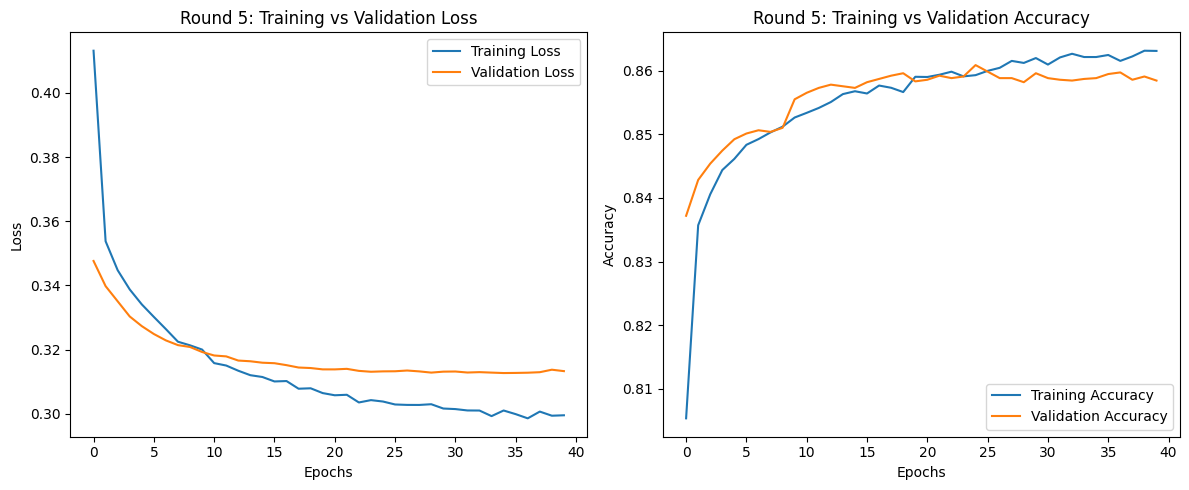

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Round 5: Training vs Validation Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Round 5: Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

Round 5 used Optuna tuning to automatically search for better hyperparameter combinations. The final Optuna model achieved the best overall ROC AUC score of 0.9092, which was slightly higher than the previous manual experiments.

The loss curves show that both training and validation loss decreased steadily, while validation loss began to flatten after around 20 epochs. The accuracy curves also stayed close together, suggesting that the model generalized reasonably well with only mild overfitting near the later epochs.

Overall, Optuna improved performance slightly compared to the manual rounds, but the improvement was modest. This suggests that the earlier models were already fairly strong, and tuning mainly helped refine the model rather than dramatically change performance.

# Evaluate your final model

In [72]:
results_df = pd.DataFrame({
    "Model": [
        "Baseline",
        "Round 1: Dropout",
        "Round 2: Larger Model",
        "Round 3: L2 Regularization",
        "Round 4: Dropout + EarlyStopping",
        "Round 5: Optuna Tuning"
    ],
    "Accuracy": [0.8503, 0.8535, 0.8482, 0.8521, 0.8487, 0.8548],
    "Precision": [0.6986, 0.7467, 0.6901, 0.8491, 0.6982, 0.8488],
    "Recall": [0.6588, 0.5869, 0.6644, 0.8521, 0.6485, 0.8548],
    "F1 Score": [0.6781, 0.6572, 0.6770, 0.8504, 0.6724, 0.8499],
    "ROC AUC": [0.9084, 0.9065, 0.9071, 0.9067, 0.9069, 0.9092]
})

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Baseline,0.8503,0.6986,0.6588,0.6781,0.9084
1,Round 1: Dropout,0.8535,0.7467,0.5869,0.6572,0.9065
2,Round 2: Larger Model,0.8482,0.6901,0.6644,0.6770,0.9071
3,Round 3: L2 Regularization,0.8521,0.8491,0.8521,0.8504,0.9067
4,Round 4: Dropout + EarlyStopping,0.8487,0.6982,0.6485,0.6724,0.9069
5,Round 5: Optuna Tuning,0.8548,0.8488,0.8548,0.8499,0.9092


The final Optuna-tuned neural network was evaluated on a held-out test set using multiple performance metrics. The final model (round5) achieved a test accuracy of 0.8548, precision of 0.8488, recall of 0.8548, F1 score of 0.8499, and ROC AUC score of 0.9092.

The training and validation curves showed stable learning behavior throughout training. Both training and validation loss steadily decreased over the epochs, while training and validation accuracy gradually increased. The validation curves remained relatively close to the training curves, indicating that the model generalized reasonably well to unseen data with only mild overfitting during later epochs.

Although the Optuna-tuned model achieved the strongest overall ROC AUC performance, the improvement over earlier experiments was relatively small. This suggests that the baseline model was already fairly effective for the Adult Census dataset, and increasing model complexity produced only modest performance gains. Overall, the final model demonstrated stable classification performance and good generalization ability on the held-out test set, although the improvements over the baseline model were relatively modest.

# Personal Workflow

Through this assignment, I learned that neural network development should follow a structured experimental workflow rather than randomly increasing model complexity.

I would first begin with a simple baseline model to understand the dataset and observe whether the model initially underfits or overfits. After establishing baseline behavior, I would systematically test one modification at a time, such as adding dropout, increasing hidden layers, adjusting training setups, or applying L2 regularization, in order to better understand how each change affects training and validation performance.

I also learned that increasing model complexity does not always improve model performance. In several experiments, deeper architectures slightly improved training accuracy while providing only modest improvements in validation ROC AUC. Regularization methods such as dropout and L2 mainly helped stabilize training behavior rather than dramatically increasing predictive performance.

Finally, I found that Optuna tuning was an efficient way to identify stronger hyperparameter combinations after completing manual experimentation. Instead of manually testing every possible configuration, Optuna systematically searched for improved learning rates, dropout rates, layer sizes, and batch sizes.

Overall, this assignment improved my understanding of how architecture design, regularization, training setup, and hyperparameter tuning interact during neural network development.